# Data Visualization - Titanic Excersize

Imports

In [1167]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
sns.set_theme(style="whitegrid", palette="deep")
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib import cm, colors
import numpy as np


In [1168]:
df = pd.read_excel("titanic.xls")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Helpers

In [1169]:
def line_plot_with_bubbles(df :pd.DataFrame, x : str, y : str, z : str, plot_line=True, plot_mean= True):
    if plot_line:
        plt.plot(
            df[x],
            df[y],
            marker="o",              
            linestyle="-",           
            color="tab:blue",
            linewidth=2
        )

    plt.scatter(
        df[x],
        df[y],
        s=df[z] * 3,  
        color="tab:blue",
        alpha=0.7
    )


    for x_loc, y_loc, count in zip(
        df[x],
        df[y],
        df[z]
    ):
        plt.text(
            x_loc, y_loc,                      
            str(count),                
            ha="center", va="center",  
            fontsize=8, color="black",
            fontweight="bold"
        )

    if plot_mean:
        num_survivers = np.sum(np.array(df[y]) * np.array(df[z]))
        mean_survival = num_survivers / float(np.sum(np.array(df[z])))
        plt.axhline(
            mean_survival,
            linestyle="--",
            linewidth=1,
            color="orange",
            label=f"Mean {y} ({mean_survival:.1f}%)"
        )
        plt.legend()
    

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} by {x} (Bubble size = number of passengers of the {x})\n", fontweight="bold")
    plt.grid(True)
    plt.ylim(-5,105)
    plt.xticks(df[x], rotation=45)
    plt.tight_layout()

def bar_plot_with_bubbles(df :pd.DataFrame, x : str, y : str, z : str, plot_mean= True):
    normalized_z = df[z] / df[z].sum()
    for x_val, y_val, z_val in zip(df[x], df[y], normalized_z):
        plt.bar(
            x_val,
            y_val,              
            linestyle="-",           
            color="tab:blue",
            edgecolor = "black",
            width = min(0.25 + z_val, 1) 
        )



    for x_loc, y_loc, count in zip(
        df[x],
        df[y],
        df[z]
    ):
        plt.text(
            x_loc, y_loc + 1,                      
            str(count),                
            ha="center", va="center",  
            fontsize=10, color="black",
            fontweight="bold"
        )

    if plot_mean:
        num_survivers = np.sum(np.array(df[y]) * np.array(df[z]))
        mean_survival = num_survivers / float(np.sum(np.array(df[z])))
        plt.axhline(
            mean_survival,
            linestyle="--",
            linewidth=1,
            color="orange",
            label=f"Mean {y} ({mean_survival:.1f}%)"
        )
        plt.legend()
    

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} by {x} (Number on top = number of passengers of the {x})\n", fontweight="bold")
    plt.grid(True)
    plt.ylim(-5,105)
    plt.xticks(df[x], rotation=45)
    plt.tight_layout()

Interesting Dataset Statistics

num_people 1309
survival_rate 0.3819709702062643


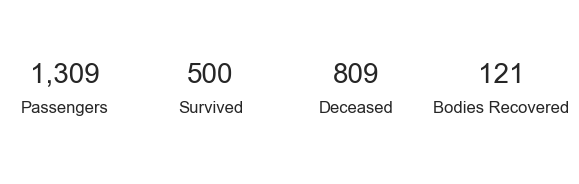

In [1229]:
num_people = len(df)
survival_rate = df["survived"].sum() / float(num_people)
print("num_people", num_people)
print("survival_rate",survival_rate)
for survival, group_df in df.groupby("survived"):
    if not survival:
        num_deceased = len(group_df)
        num_recovered_numbers = df['body'].notna().sum()
plt.figure(figsize=(6,2))

plt.subplot(1,4,1)
plt.text(0.5, 0.6, f"{num_people:,}", fontsize=20,
         ha='center', va='center')
plt.text(0.5, 0.4, "Passengers", fontsize=12,
         ha='center', va='center')
plt.axis('off')

plt.subplot(1,4,2)
plt.text(0.5, 0.6, f"{num_people - num_deceased}", fontsize=20,
         ha='center', va='center')
plt.text(0.5, 0.4, "Survived", fontsize=12,
         ha='center', va='center')
plt.axis('off')

plt.subplot(1,4,3)
plt.text(0.5, 0.6, f"{num_deceased}", fontsize=20,
         ha='center', va='center')
plt.text(0.5, 0.4, "Deceased", fontsize=12,
         ha='center', va='center')
plt.axis('off')

plt.subplot(1,4,4)
plt.text(0.5, 0.6, f"{num_recovered_numbers:,}", fontsize=20,
         ha='center', va='center')
plt.text(0.5, 0.4, "Bodies Recovered", fontsize=12,
         ha='center', va='center')
plt.axis('off')

plt.tight_layout()

plt.show() 


Dataset Completeness

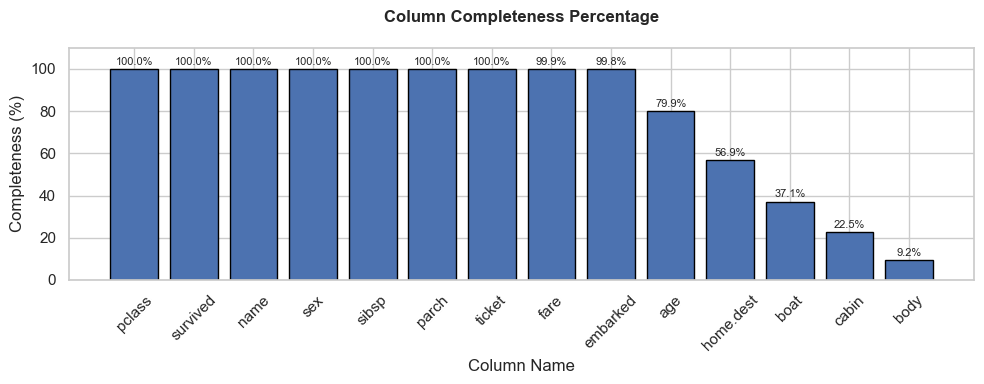

In [1192]:
completeness_percent = (df.notna().mean() * 100)
completeness_percent = completeness_percent.sort_values(ascending=False)

plt.figure(figsize=(10,4))
bars = plt.bar(completeness_percent.index, completeness_percent.values, edgecolor="black")

plt.xticks(rotation=45)
plt.ylabel("Completeness (%)")
plt.xlabel("Column Name")
plt.title("Column Completeness Percentage\n", fontweight = "bold")
plt.ylim(0, 110)   


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + 1,                       
        f"{height:.1f}%",                 
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.show()


### How is age distributed over different parameters?

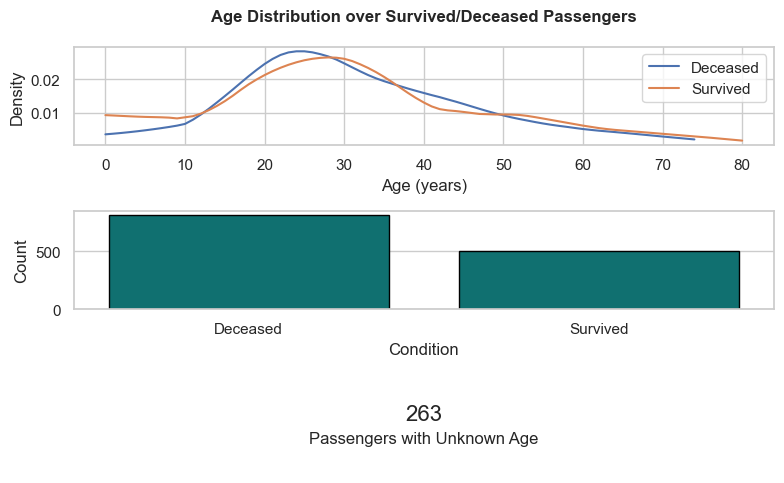

In [1171]:
plt.figure(figsize=(8,5))
ages_df = df.copy()
unkown_ages_count = df["age"].isna().sum() 
total_passengers_per_condition = []
conditions = []
for value, group_df in ages_df.groupby("survived"):
    group_df["rounded_age"] = group_df["age"].round()
    age_counts = group_df.groupby("rounded_age")["survived"].count()
    age, count = age_counts.index.to_numpy(), age_counts.to_numpy() 
    counts_normalized = count / sum(count)
    smooth = lowess(counts_normalized, age, frac=0.3, return_sorted=False)
    survived = "Survived" if value else "Deceased" 
    conditions.append(survived)
    total_passengers_per_condition.append(len(group_df))
    plt.subplot(3,1,1)
    sns.lineplot(
        x = age,
        y = smooth,
        label = survived
    )   
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.title("Age Distribution over Survived/Deceased Passengers\n", fontweight="bold")
plt.legend()

plt.subplot(3,1,2)
amoutns_df = pd.DataFrame({
    "Condition" : conditions,
    "Count" : total_passengers_per_condition
})
sns.barplot(data =amoutns_df, x ="Condition",y="Count", color="teal", edgecolor = "black" )

plt.subplot(3,1,3)
# Big number
plt.text(0.5, 0.6, f"{unkown_ages_count:,}", fontsize=16,
         ha='center', va='center')

# Smaller description
plt.text(0.5, 0.35, "Passengers with Unknown Age", fontsize=12,
         ha='center', va='center')

plt.axis('off')

plt.tight_layout()

plt.show()

Distribution of ages per passenger class

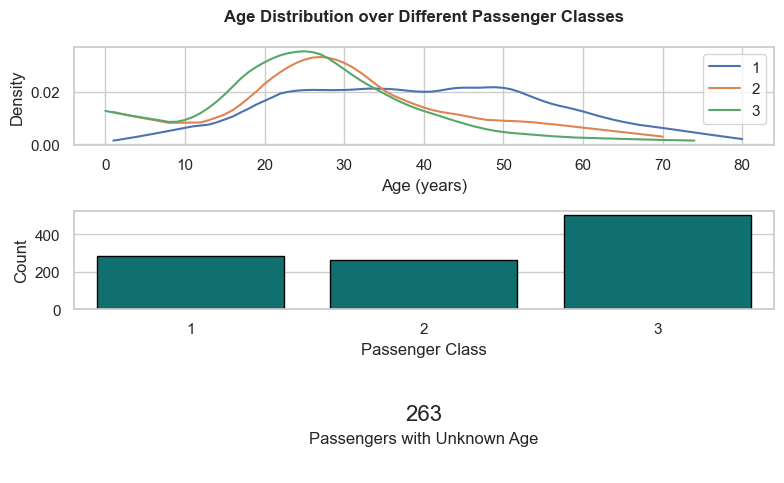

In [1172]:
plt.figure(figsize=(8,5))

ages_df = df.dropna(subset=["age"])
total_passengers_per_pclass = []
p_classes = []
for value, group_df in ages_df.groupby("pclass"):
    group_df["rounded_age"] = group_df["age"].round()
    age_counts = group_df.groupby("rounded_age")["pclass"].count()
    age, count = age_counts.index.to_numpy(), age_counts.to_numpy() 
    counts_normalized = count / sum(count)
    smooth = lowess(counts_normalized, age, frac=0.3, return_sorted=False)
    p_classes.append(value)
    total_passengers_per_pclass.append(len(group_df))
    plt.subplot(3,1,1)
    sns.lineplot(
        x = age,
        y = smooth,
        label = value
    )   
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.title("Age Distribution over Different Passenger Classes\n", fontweight="bold")
plt.legend()

plt.subplot(3,1,2)
amoutns_df = pd.DataFrame({
    "Passenger Class" : p_classes,
    "Count" : total_passengers_per_pclass
})
sns.barplot(data =amoutns_df, x ="Passenger Class",y="Count", color="teal", edgecolor = "black")
plt.subplot(3,1,3)
# Big number
plt.text(0.5, 0.6, f"{unkown_ages_count:,}", fontsize=16,
         ha='center', va='center')

# Smaller description
plt.text(0.5, 0.35, "Passengers with Unknown Age", fontsize=12,
         ha='center', va='center')

plt.axis('off')
plt.tight_layout()

plt.show()

In [1173]:
binned_ages_df = ages_df.copy()
binned_ages_df["binned_age"] = pd.cut(df["age"], bins=[5*x for x in range(0,20)], right=False)
ages = []
percentages = []
total_counts = []
for age, group_df in binned_ages_df.groupby("binned_age"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    if total_count > 0: 
        ages.append(str(age))
        percentages.append((survived_count/float(total_count)) * 100)
        total_counts.append(total_count)

binned_ages_df = pd.DataFrame(
    {
        "Age": ages,
        "Survival Percentage" : percentages,
        "Total Count" : total_counts
    }
)


C:\Users\user\AppData\Local\Temp\ipykernel_19244\2513777002.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for age, group_df in binned_ages_df.groupby("binned_age"):


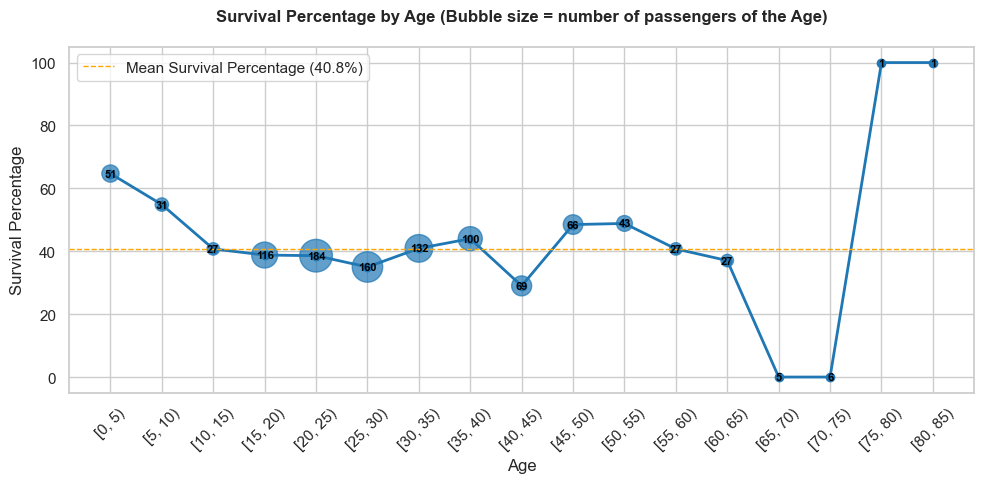

In [1174]:
plt.figure(figsize=(10,5))
line_plot_with_bubbles(df = binned_ages_df, x="Age", y="Survival Percentage", z="Total Count")

In [1246]:
pclasses = []
percentages = []
total_counts = []
for pclass, group_df in df.groupby("pclass"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    pclasses.append(pclass)
    percentages.append((survived_count/float(total_count)) * 100)
    total_counts.append(total_count)

passenger_class_df = pd.DataFrame(
    {
        "Passenger Class" : pclasses,
        "Survival Percentage (%)" : percentages,
        "Total Count" : total_counts
    }
)



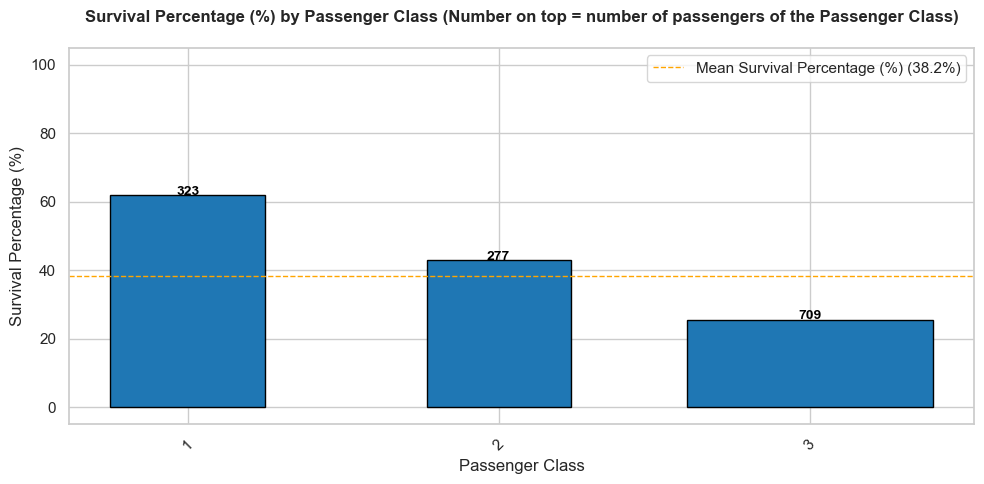

In [1247]:
plt.figure(figsize=(10,5))
bar_plot_with_bubbles(df=passenger_class_df, x="Passenger Class", y="Survival Percentage (%)", z="Total Count")

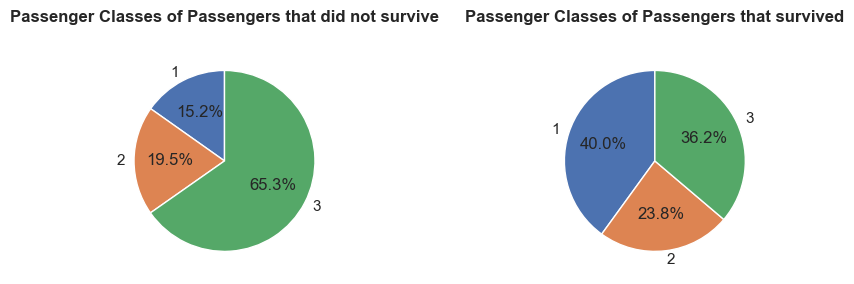

In [1199]:
plt.figure(figsize=(10,3))
for i, (survival, group_df) in enumerate(df.groupby("survived")):
    total_number_of_passengers_in_group = len(group_df)
    percentages = []
    pclasses = []
    for pclass, subgroup_df in group_df.groupby("pclass"):
        number_of_passengers_in_pclass = float(len(subgroup_df))
        pclasses.append(pclass)
        percentages.append(number_of_passengers_in_pclass/total_number_of_passengers_in_group)
    plt.subplot(1,2,i+1)
    survived = "survived" if survival else "did not survive"
    plt.title(f"Passenger Classes of Passengers that {survived}\n", fontweight="bold")
    plt.pie(percentages,labels =pclasses, autopct='%1.1f%%', startangle=90)

plt.tight_layout()
plt.show()


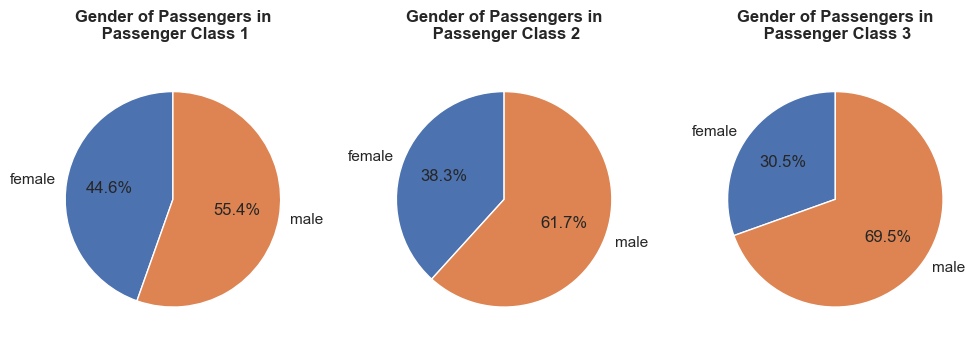

In [1202]:
plt.figure(figsize= (10,4))
for i, (pclass, group_df) in enumerate(df.groupby("pclass")):
    total_number_of_passengers_in_pclass = len(group_df)
    percentages = []
    genders = []
    for sex, subgroup_df in group_df.groupby("sex"):
        number_of_passengers_in_sex = len(subgroup_df)
        genders.append(sex)
        percentages.append(number_of_passengers_in_sex/float(total_number_of_passengers_in_pclass))
    plt.subplot(1,3,i+1)
    plt.title(f"Gender of Passengers in\n Passenger Class {pclass}\n", fontweight="bold")
    plt.pie(percentages,labels =genders, autopct='%1.1f%%', startangle=90)

plt.tight_layout()
plt.show()

### Which family had lost the most members?

Families with most losses are: ['Andersson', 'Sage']


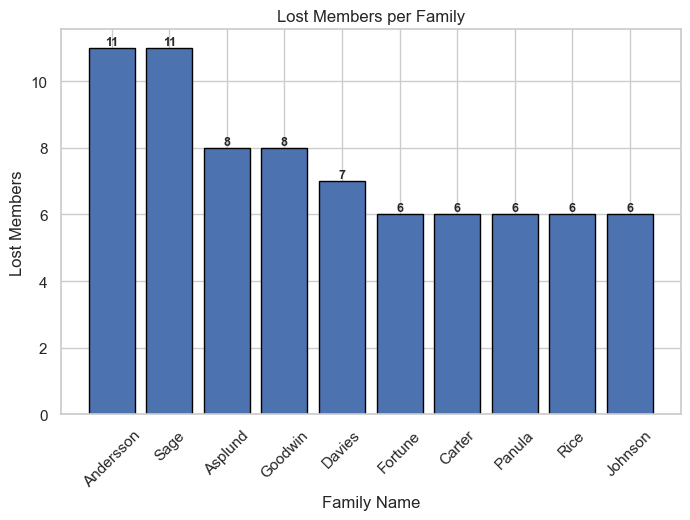

In [1179]:
family_df = df.copy()
family_df["name"] = family_df["name"].str.split(",").str[0]
family_df["dead"] = family_df["survived"] == 0
family_df.head()
family_member_loss = family_df.groupby("name")["dead"].count().sort_values(ascending=False)

most_losses = family_member_loss.iloc[0]
most_losses_families = family_member_loss[family_member_loss == most_losses].index
print(f"Families with most losses are: {most_losses_families.tolist()}")

top_k = 10
top_k_family_names = family_member_loss.index.tolist()[:top_k]
top_k_dead_count = family_member_loss.tolist()[:top_k]

plt.figure(figsize=(8,5))
plt.xticks(rotation=45)
bars = plt.bar(top_k_family_names,top_k_dead_count, edgecolor = "black")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  
        int(height),                      
        f"{height:.0f}",                  
        ha="center", va="bottom",         
        fontsize=9, fontweight="bold"
    )

plt.ylabel("Lost Members")
plt.xlabel("Family Name")
plt.title("Lost Members per Family")
plt.show()

And assuming a family is defined by ticket number

Families with most losses are: Sage


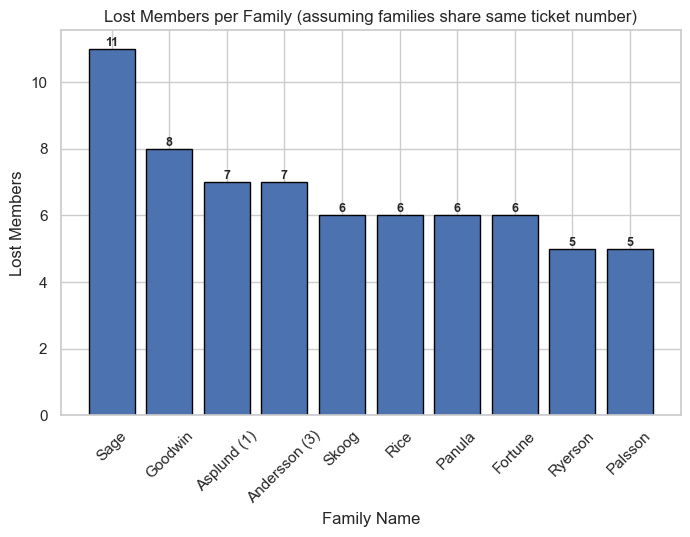

In [1180]:
new_families = []
counts = []
for family in family_member_loss.index:
    tickets = np.array(family_df[family_df["name"] == family]["ticket"], dtype = str)
    new_names = np.unique(tickets, return_counts=True)
    if len(new_names[1]) == 1:
        new_families.append(family)
        counts.append(new_names[1][0])
        continue
    for i, (ticket, count)  in enumerate(zip(new_names[0], new_names[1])):
        new_families.append(f"{family} ({i+1})")
        counts.append(count)
sorted_new_families = [s for _, s in sorted(zip(counts, new_families), reverse=True)]
sorted_counts  = [c for c, _ in sorted(zip(counts, new_families), reverse=True)]

most_losses = sorted_new_families[0]
most_losses_families = sorted_new_families[counts == most_losses]
print(f"Families with most losses are: {most_losses_families}")

top_k = 10
top_k_family_names = sorted_new_families[:top_k]
top_k_dead_count = sorted_counts[:top_k]

plt.figure(figsize=(8,5))
plt.xticks(rotation=45)
bars = plt.bar(top_k_family_names,top_k_dead_count, edgecolor = "black")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  
        int(height),                           
        f"{height:.0f}",                  
        ha="center", va="bottom",         
        fontsize=9, fontweight="bold"
    )

plt.ylabel("Lost Members")
plt.xlabel("Family Name")
plt.title("Lost Members per Family (assuming families share same ticket number)")
plt.show()

### Extras

Per Gender Survival

In [1244]:
sexes = []
percentages = []
total_counts = []
for sex, group_df in df.groupby("sex"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    total_counts.append(total_count)
    sexes.append(sex)
    percentages.append((survived_count/float(total_count)) * 100)

gender_df = pd.DataFrame(
    {
        "Gender" : sexes,
        "Survival Percentage (%)" : percentages,
        "Total Count":  total_counts
    }
)


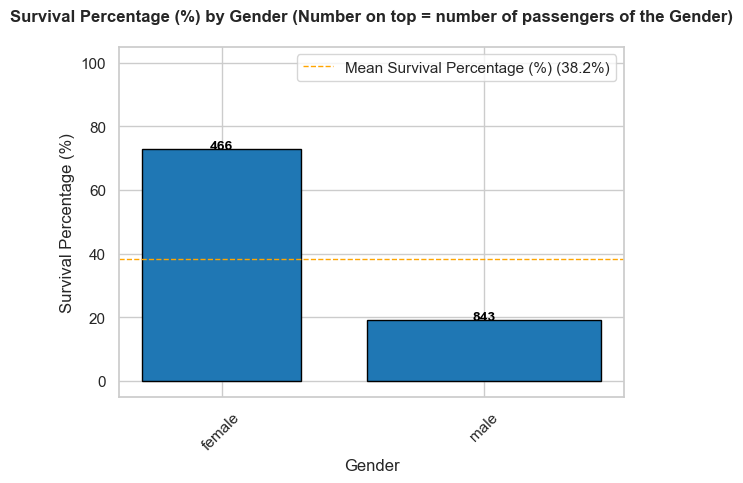

In [1245]:
plt.figure(figsize=(6,5))
bar_plot_with_bubbles(df=gender_df, x="Gender", y="Survival Percentage (%)", z="Total Count")


How did embarked port affect survival rate? 

In [1242]:
ports = []
percentages = []
total_counts = []
embarked_df = df.copy()
embarked_df["embarked"] = embarked_df["embarked"].fillna("Unkown")
for port, group_df in embarked_df.groupby("embarked"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    total_counts.append(total_count)
    ports.append(port)
    percentages.append((survived_count/float(total_count)) * 100)

embarked_df = pd.DataFrame(
    {
        "Embarked Port" : ports,
        "Survival Percentage (%)" : percentages,
        "Total Count":  total_counts
    }
)

# fig, ax = plt.subplots()
# ax.bar(ports, [100]*len(ports), color="#CB0E14", edgecolor = "black")
# green_bar = ax.bar(ports, percentages, color="#28A728", edgecolor = "black")
# ax.set_ylabel("Survival Percentage (%)")
# ax.set_xlabel("Embarked Port")
# ax.set_xticks(ports)
# ax.bar_label(green_bar, fmt='%.2f')
# ax.set_title("Survival Percentage per Embarked Port")

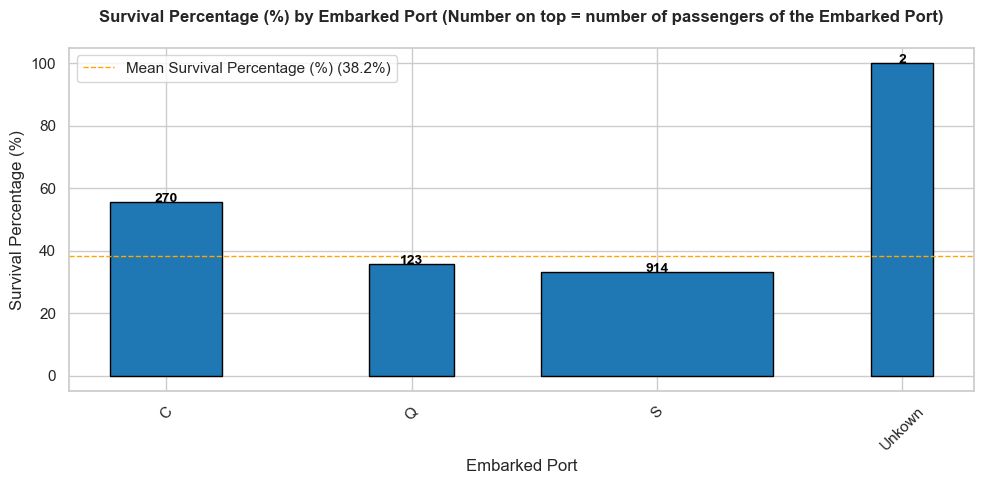

In [1243]:
plt.figure(figsize=(10,5))
bar_plot_with_bubbles(embarked_df, "Embarked Port", "Survival Percentage (%)", "Total Count")


Fare by Class

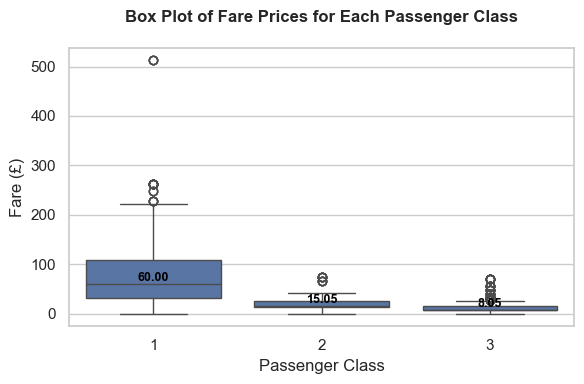

In [1214]:
fare_by_pclass = {}
unknown_fare_count = df["fare"].isna().sum()

for pclass, group_df in df.groupby("pclass"):
    fare_by_pclass[pclass] = group_df["fare"]

fare_df = pd.DataFrame({
    "Passenger Class": [k for k, v in fare_by_pclass.items() for _ in v],
    "Fare (£)":    [val for v in fare_by_pclass.values() for val in v]
})

plt.figure(figsize=(6,4))
sns.boxplot(data=fare_df, x="Passenger Class", y="Fare (£)")
plt.title("Box Plot of Fare Prices for Each Passenger Class\n", fontweight = "bold")
medians = fare_df.groupby("Passenger Class")["Fare (£)"].median()

# Annotate
for tick, pclass in enumerate(medians.index):
    median_val = medians[pclass]
    plt.text(
        tick, median_val,
        f"{median_val:.2f}",
        horizontalalignment='center',
        verticalalignment='bottom',
        fontsize=9,
        fontweight='bold',
        color='black'
    )
plt.tight_layout()
plt.show()


The box shows the middle 50% of the data (from Q1 to Q3).

The line inside the box is the median.

The “whiskers” extend to data points that are within a certain range - (Q1 – 1.5 × IQR, Q3 + 1.5 × IQR), where IQR = Q3 − Q1

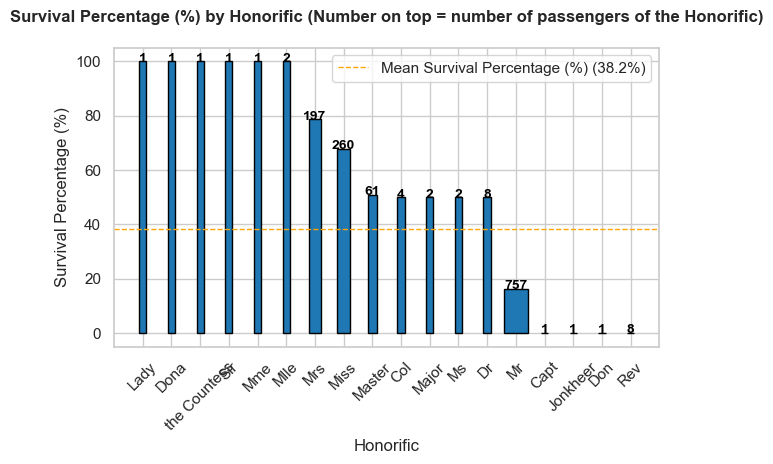

In [1241]:
honorific_df = df.copy()
honorific_df["honorific"] = honorific_df["name"].str.split(",").str[1].str.split(".").str[0].str[1:]
honorific_df["dead"] = honorific_df["survived"] == 0
honorific_df.head()
honorifics = []
total_counts = []
percentages = []

for honorific, group_df in honorific_df.groupby("honorific"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    if total_count > 0: 
        honorifics.append(honorific)
        percentages.append((survived_count/float(total_count)) * 100)
        total_counts.append(total_count)
honorific_df = pd.DataFrame({
    "Honorific" : honorifics,
    "Survival Percentage (%)" : percentages,
    "Total Count" : total_counts
}).sort_values(by="Survival Percentage (%)", ascending=False)


bar_plot_with_bubbles(honorific_df, x="Honorific",y="Survival Percentage (%)", z="Total Count")

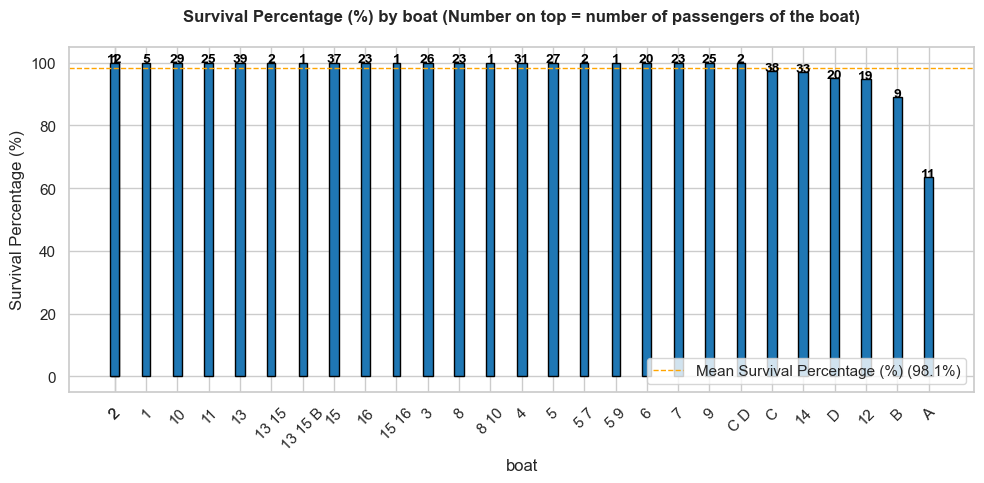

In [1248]:
boats = []
total_counts = []
percentages = []

for boat, group_df in df.groupby("boat"):
    survived_count = group_df["survived"].sum()
    total_count = len(group_df)
    if total_count > 0: 
        boats.append(str(boat))
        percentages.append((survived_count/float(total_count)) * 100)
        total_counts.append(total_count)
boat_df = pd.DataFrame({
    "boat" : boats,
    "Survival Percentage (%)" : percentages,
    "Total Count" : total_counts
}).sort_values(by="Survival Percentage (%)", ascending=False)

plt.figure(figsize=(10,5))
bar_plot_with_bubbles(boat_df, x="boat",y="Survival Percentage (%)", z="Total Count")
